In [1]:
# ==============================================================================
# IMPORT LIBRARY YANG DIBUTUHKAN
# ==============================================================================
import pandas as pd # untuk manipulasi data tabel (seperti Excel)
import re # untuk regular expression (pembersihan teks)
import matplotlib.pyplot as plt # untuk visualisasi data (grafik)
import seaborn as sns # untuk visualisasi Confusion Matrix yang lebih cantik

# LIBRARY NATURAL LANGUAGE PROCESSING (NLTK) untuk Preprocessing
import nltk
from nltk.tokenize import word_tokenize # untuk memecah kalimat menjadi kata
from nltk.corpus import stopwords # Daftar kata umum (stopwords)

# Library Scikit-Learn untuk Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer # Mengubah teks menjadi bentuk angka (vektor) menggunakan TF-IDF
from sklearn.feature_selection import SelectKBest, chi2 # Seleksi fitur terbaik berdasarkan statistik chi-square
# Model Decision Tree untuk klasifikasi
from sklearn.tree import DecisionTreeClassifier  
# Visualisasi pohon keputusan
from sklearn.tree import plot_tree  
# Menampilkan aturan decision tree dalam bentuk teks
from sklearn.tree import export_text  
# Evaluasi model machine learning
from sklearn.metrics import (
    classification_report,   # precision, recall, f1-score
    accuracy_score,          # akurasi model
    confusion_matrix,        # matriks prediksi vs aktual
    ConfusionMatrixDisplay   # visualisasi confusion matrix
)

# Download resource NLTK yang diperlukan
# 'punkt' dan 'punkt_tab': Untuk Tokenization
# 'stopwords'            : Untuk kamus Stopwords (the, is, a, …)
for resource in ["punkt", "punkt_tab", "stopwords"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [2]:
# ==============================================================================
# TAHAP 1: PERSIAPAN DATA (FILTERING & MAPPING)
# ==============================================================================

print("Membaca dataset dari Kaggle...")

# Input file path data training
training_data_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/train.csv'
testing_data_path = '/kaggle/input/datasets/amananandrai/ag-news-classification-dataset/test.csv'

df_train_raw = pd.read_csv(training_data_path)
df_test_raw = pd.read_csv(testing_data_path)

Membaca dataset dari Kaggle...


In [3]:
display(df_train_raw.head(5))
print(f"Jumlah data training: {len(df_train_raw)}")
display(df_test_raw.head(5))
print(f"Jumlah data testing: {len(df_test_raw)}")

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


Jumlah data training: 120000


,Class Index,Title,Description
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o..."
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...


Jumlah data testing: 7600


In [4]:
# Menggabungkan Judul dan Deskripsi Berita
df_train_raw['text'] = df_train_raw['Title'] + " " + df_train_raw['Description']
df_test_raw['text'] = df_test_raw['Title'] + " " + df_test_raw['Description']

In [5]:
display(df_train_raw.head(5))
print(f"Jumlah data training: {len(df_train_raw)}")
display(df_test_raw.head(5))
print(f"Jumlah data testing: {len(df_test_raw)}")

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


Jumlah data training: 120000


,Class Index,Title,Description,text
0,3,Fears for T N pension after talks,Unions representing workers at Turner Newall...,Fears for T N pension after talks Unions repre...
1,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...
2,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...
3,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...
4,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...


Jumlah data testing: 7600


In [6]:
# Membuang Class Index = 3 (Business) agar sesuai requirement 3 kelas saja
# Mapping Kelas ke Bahasa Indonesia (1=World, 2=Sports, 4=Sci/Tech)

TARGET_LABELS = {
    1: "Politik", 
    2: "Olahraga", 
    4: "Teknologi"
}
 
def filter_and_map(df):
    """
    Menyaring baris hanya untuk label 1, 2, 4 lalu
    memetakan angka ke nama kategori yang sesuai.
    """
    df = df[df["Class Index"].isin(TARGET_LABELS.keys())].copy()
    df["label"] = df["Class Index"].map(TARGET_LABELS)
    return df.reset_index(drop=True)
 
df_train_clean = filter_and_map(df_train_raw)
df_test_clean  = filter_and_map(df_test_raw)

In [7]:
# Menyimpan hasil preprocessing ke file CSV
df_train_clean.to_csv("train_clean.csv", index=False)
df_test_clean.to_csv("test_clean.csv", index=False)

print("File train_clean.csv dan test_clean.csv berhasil disimpan.")

File train_clean.csv dan test_clean.csv berhasil disimpan.


In [8]:
display(df_train_clean.head(5))
print(f"Jumlah data training: {len(df_train_clean)}")
display(df_test_clean.head(5))
print(f"Jumlah data testing: {len(df_test_clean)}")

,Class Index,Title,Description,text,label
0,4,"'Madden,' 'ESPN' Football Score in Different W...",Reuters - Was absenteeism a little high\on Tue...,"'Madden,' 'ESPN' Football Score in Different W...",Teknologi
1,4,Group to Propose New High-Speed Wireless Forma...,Reuters - A group of technology companies\incl...,Group to Propose New High-Speed Wireless Forma...,Teknologi
2,4,AOL to Sell Cheap PCs to Minorities and Senior...,Reuters - America Online on Thursday said it\p...,AOL to Sell Cheap PCs to Minorities and Senior...,Teknologi
3,4,Companies Approve New High-Capacity Disc Forma...,Reuters - A group of consumer electronics\make...,Companies Approve New High-Capacity Disc Forma...,Teknologi
4,4,Missing June Deals Slow to Return for Software...,Reuters - The mystery of what went wrong for t...,Missing June Deals Slow to Return for Software...,Teknologi


Jumlah data training: 90000


,Class Index,Title,Description,text,label
0,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...,Teknologi
1,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...,Teknologi
2,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...,Teknologi
3,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...,Teknologi
4,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...,Open Letter Against British Copyright Indoctri...,Teknologi


Jumlah data testing: 5700


In [9]:
# ==========================================
# TAHAP 2: PREPROCESSING
# ==========================================
print("2. Memulai proses Preprocessing...")

# Ambil daftar stopword bahasa Inggris dari NLTK
stop_words_english = set(stopwords.words('english'))

2. Memulai proses Preprocessing...


In [10]:
print(stop_words_english)
print("Jumlah stopword:", len(stop_words_english))

{"doesn't", 'with', 'and', 'i', 'in', 'is', 'did', 'few', "shan't", 'between', 'hasn', 'y', 'below', 'so', "they'll", 're', "couldn't", 'shouldn', "isn't", 'doesn', 'only', 'off', 'haven', 'itself', 'or', "we'll", "haven't", 'there', "don't", 'our', 'will', 'ours', 'she', 'over', 'couldn', 'too', 'are', 'needn', "should've", 'her', 'd', 'both', 'aren', 'those', 'having', 'into', 'to', 'mightn', 'why', 'during', 'yourself', 'if', 'at', 'been', 'each', 'but', "wasn't", 'which', 'herself', "shouldn't", 'doing', "it'd", "you'd", 'from', "he's", 'can', "you've", "they've", 'nor', "i'd", 'no', 'by', 'what', 's', 'these', "we've", 'be', 'won', 'after', 'about', 'because', 'does', 'just', 'once', 'same', 'yours', "hasn't", 'wasn', 'we', 'more', 'some', 'me', "she'll", "hadn't", 'own', 't', 'you', 'not', 'under', 'ain', 'where', "they'd", "didn't", 'all', 'him', 'had', 'has', 'didn', 've', "i'm", 'he', 'theirs', "won't", 'any', 'a', 'other', 'whom', 'himself', 'ourselves', 'out', 'm', 'against'

In [11]:
def preprocess(text):
    # Case Folding: Mengubah seluruh huruf menjadi huruf kecil
    text = text.lower()
    
    text = re.sub(r'[^a-z\s]', ' ', text)     # Hapus angka & tanda baca
    text = re.sub(r'\s+', ' ', text).strip()  # Rapikan spasi berlebih
    
    # Tokenization: Memecah kalimat utuh menjadi potongan kata (list)
    tokens = word_tokenize(text)
    
    # Stopword Removal: Membuang kata-kata sambung/umum yang tidak penting
    clean_tokens = [
        token for token in tokens
        if token not in stop_words_english and len(token) > 1
    ]
    
    # Gabungkan kembali list kata menjadi string (karena TF-IDF butuh input string)
    preprocessed_text = " ".join(clean_tokens)
    return preprocessed_text

# Terapkan preprocessing ke data latih dan data uji
print("   -> Memproses Data Training...")
df_train_clean['clean_text'] = df_train_clean['text'].apply(preprocess)

print("   -> Memproses Data Testing...")
df_test_clean['clean_text'] = df_test_clean['text'].apply(preprocess)

   -> Memproses Data Training...
   -> Memproses Data Testing...


In [12]:
display(df_train_clean.head(5))
print(f"Jumlah data training: {len(df_train_clean)}")
display(df_test_clean.head(5))
print(f"Jumlah data testing: {len(df_test_clean)}")

,Class Index,Title,Description,text,label,clean_text
0,4,"'Madden,' 'ESPN' Football Score in Different W...",Reuters - Was absenteeism a little high\on Tue...,"'Madden,' 'ESPN' Football Score in Different W...",Teknologi,madden espn football score different ways reut...
1,4,Group to Propose New High-Speed Wireless Forma...,Reuters - A group of technology companies\incl...,Group to Propose New High-Speed Wireless Forma...,Teknologi,group propose new high speed wireless format r...
2,4,AOL to Sell Cheap PCs to Minorities and Senior...,Reuters - America Online on Thursday said it\p...,AOL to Sell Cheap PCs to Minorities and Senior...,Teknologi,aol sell cheap pcs minorities seniors reuters ...
3,4,Companies Approve New High-Capacity Disc Forma...,Reuters - A group of consumer electronics\make...,Companies Approve New High-Capacity Disc Forma...,Teknologi,companies approve new high capacity disc forma...
4,4,Missing June Deals Slow to Return for Software...,Reuters - The mystery of what went wrong for t...,Missing June Deals Slow to Return for Software...,Teknologi,missing june deals slow return software cos re...


Jumlah data training: 90000


,Class Index,Title,Description,text,label,clean_text
0,4,The Race is On: Second Private Team Sets Launc...,"SPACE.com - TORONTO, Canada -- A second\team o...",The Race is On: Second Private Team Sets Launc...,Teknologi,race second private team sets launch date huma...
1,4,Ky. Company Wins Grant to Study Peptides (AP),AP - A company founded by a chemistry research...,Ky. Company Wins Grant to Study Peptides (AP) ...,Teknologi,ky company wins grant study peptides ap ap com...
2,4,Prediction Unit Helps Forecast Wildfires (AP),AP - It's barely dawn when Mike Fitzpatrick st...,Prediction Unit Helps Forecast Wildfires (AP) ...,Teknologi,prediction unit helps forecast wildfires ap ap...
3,4,Calif. Aims to Limit Farm-Related Smog (AP),AP - Southern California's smog-fighting agenc...,Calif. Aims to Limit Farm-Related Smog (AP) AP...,Teknologi,calif aims limit farm related smog ap ap south...
4,4,Open Letter Against British Copyright Indoctri...,The British Department for Education and Skill...,Open Letter Against British Copyright Indoctri...,Teknologi,open letter british copyright indoctrination s...


Jumlah data testing: 5700


In [13]:
# Tampilkan perbandingan sebelum dan sesudah Preprocessing
print("\n--- Contoh Hasil Preprocessing ---")
for i in range(3):
    print(f"\n[{i+1}] ORIGINAL  : {df_train_clean['text'].iloc[i]}")
    print(f"    CLEAN     : {df_train_clean['clean_text'].iloc[i]}")
    print(f"    LABEL     : {df_train_clean['label'].iloc[i]}")


--- Contoh Hasil Preprocessing ---

[1] ORIGINAL  : 'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\on Tuesday among the guys at the office? EA Sports would like\to think it was because "Madden NFL 2005" came out that day,\and some fans of the football simulation are rabid enough to\take a sick day to play it.
    CLEAN     : madden espn football score different ways reuters reuters absenteeism little high tuesday among guys office ea sports would like think madden nfl came day fans football simulation rabid enough take sick day play
    LABEL     : Teknologi

[2] ORIGINAL  : Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\including Texas Instruments Inc. (TXN.N), STMicroelectronics\(STM.PA) and Broadcom Corp. (BRCM.O), on Thursday said they\will propose a new wireless networking standard up to 10 times\the speed of the current generation.
    CLEAN     : group propose new high spee

In [14]:
# Pisahkan Fitur (X) dan Target (y)
X_train = df_train_clean['clean_text']
y_train = df_train_clean['label']

X_test = df_test_clean['clean_text']
y_test = df_test_clean['label']

In [15]:
# ==========================================
# TAHAP 3: REPRESENTASI
# ==========================================
print("\n3. Melakukan Representasi Teks (TF-IDF & Feature Selection)...")

# a. TF-IDF
# MAX_FEATURES = 20000   # Ambil 20.000 kata/frasa paling informatif
vectorizer = TfidfVectorizer(
    # max_features=MAX_FEATURES, 
    # ngram_range=(1, 2), # unigram & bigram
)
X_train_tfidf = vectorizer.fit_transform(X_train)

vocab_size = len(vectorizer.vocabulary_)

print(f"Jumlah kosakata/vocabulary: {vocab_size}")

X_test_tfidf = vectorizer.transform(X_test)

# b. Feature Selection (Chi-square)
# Memilih 5000 fitur/kata yang memiliki korelasi terkuat dengan label kelas
K_BEST = 5000   # Pilih 5.000 fitur terbaik dari 55.000

chi2_selector = SelectKBest(chi2, k=K_BEST)
X_train_final = chi2_selector.fit_transform(X_train_tfidf, y_train)
X_test_final = chi2_selector.transform(X_test_tfidf)

# Mengambil nama-nama kata yang lolos seleksi untuk keperluan visualisasi
selected_feature_indexes = chi2_selector.get_support(indices=True)
all_words = vectorizer.get_feature_names_out()
selected_feature_words = [all_words[i] for i in selected_feature_indexes]



3. Melakukan Representasi Teks (TF-IDF & Feature Selection)...
Jumlah kosakata/vocabulary: 55586


In [16]:
# # Eksperimen mencari Hyperparameter terbaik dengan GridSearchCV (hapus comment kalau mau coba :v)
# from sklearn.model_selection import GridSearchCV

# print("Mencari parameter Decision Tree terbaik otomatis (Grid Search)...")

# # 1. Tentukan rentang parameter yang mau diuji
# param_grid = {
#     # kontrol kompleksitas pohon
#     # "max_depth": [3, 5, 8, 12, None],
#     # "min_samples_split": [2, 5, 10, 20],
#     # "min_samples_leaf": [1, 2, 5, 10],
    
#     # fungsi split
#     "criterion": ["gini", "entropy", "log_loss"],
    
#     # fitur yang dipakai saat split
#     "max_features": [None, "sqrt", "log2"],
    
#     # pruning (sangat penting untuk kurangi overfitting)
#     "ccp_alpha": [0.0, 0.0005, 0.001, 0.005, 0.01],
    
#     # handling imbalance data (opsional tapi sering membantu)
#     # "class_weight": [None, "balanced"]
# }

# # 2. Siapkan model dasar
# dt_dasar = DecisionTreeClassifier(
#     min_samples_split=20,
#     max_depth=50,
#     random_state=42
# )

# # 3. Masukkan ke GridSearchCV (cv=5 berarti melakukan Cross-Validation 5x untuk tiap kombinasi)
# grid_search = GridSearchCV(
#     estimator=dt_dasar, 
#     param_grid=param_grid, 
#     cv=5, 
#     n_jobs=-1, # Gunakan seluruh core prosesor agar cepat
#     scoring='accuracy',
#     verbose=2,
#     return_train_score=True
# )

# # 4. Latih untuk mencari yang terbaik
# grid_search.fit(X_train_final, y_train)

# # # hasil terbaik
# # print("Best Parameters:", grid_search.best_params_)
# # print("Best CV Score:", grid_search.best_score_)

# # # 5. Gunakan model terbaik tersebut untuk memprediksi
# # best_dt_model = grid_search.best_estimator_
# # y_pred = best_dt_model.predict(X_test_final)

# # print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
# # print("\nClassification Report:\n", classification_report(y_test, y_pred))

# # =========================================================
# # ANALISIS HASIL GRID SEARCH
# # =========================================================

# # ubah hasil jadi dataframe
# results = pd.DataFrame(grid_search.cv_results_)

# # hitung gap overfitting
# results['overfit_gap'] = (
#     results['mean_train_score']
#     - results['mean_test_score']
# )

# # skor gabungan:
# # validation tinggi + overfit rendah
# results['balanced_score'] = (
#     results['mean_test_score']
#     - results['overfit_gap']
# )

# # urutkan model terbaik
# results_sorted = results.sort_values(
#     by='balanced_score',
#     ascending=False
# )
# # tampilkan 10 model terbaik
# print("\n===== TOP 10 MODEL TERBAIK =====")

# cols_show = [
#     'mean_train_score',
#     'mean_test_score',
#     'overfit_gap',
#     'balanced_score',
#     'param_criterion',
#     'param_max_features',
#     'param_ccp_alpha'
# ]

# print(results_sorted[cols_show].head(10))

# # =========================================================
# # PILIH MODEL TERBAIK BERDASARKAN BALANCED SCORE
# # =========================================================

# best_index = results_sorted.index[0]

# best_params = results.loc[best_index, 'params']

# print("\n===== PARAMETER TERBAIK (Overfitting Rendah) =====")
# print(best_params)

# print("\nTrain Accuracy :",
#       results.loc[best_index, 'mean_train_score'])

# print("Validation Accuracy :",
#       results.loc[best_index, 'mean_test_score'])

# print("Overfitting Gap :",
#       results.loc[best_index, 'overfit_gap'])

# # =========================================================
# # LATIH ULANG MODEL TERBAIK
# # =========================================================

# best_dt_model = DecisionTreeClassifier(
#     **best_params,
#     min_samples_split=20,
#     max_depth=50,
#     random_state=42
# )

# best_dt_model.fit(X_train_final, y_train)

# # prediksi test set
# y_pred = best_dt_model.predict(X_test_final)

# print("\n===== HASIL TEST SET =====")
# print("Test Accuracy:", accuracy_score(y_test, y_pred))

# print("\nClassification Report:\n")
# print(classification_report(y_test, y_pred))

In [17]:
# # ==========================================
# # EKSPERIMEN berbagai depth (hapus comment kalau mau coba :v)
# # ==========================================
# print("=== EKSPERIMEN BERBAGAI DEPTH ===")

# # Tentukan daftar kedalaman (depth) yang ingin dicoba
# # None berarti pohon dibiarkan tumbuh tanpa batas
# # depths = [1, 3, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, None]
# depths = [1, None]

# # Tempat untuk menyimpan hasil akurasi
# train_scores = []
# test_scores = []
# actual_depths = []
# max_depth_unlimited = 0

# # Melakukan perulangan (looping) untuk setiap kedalaman
# for depth in depths:
#     # Jika depth adalah None, ubah label print agar rapi
#     label_depth = "Tanpa Batas" if depth is None else str(depth)
#     print(f"Melatih model dengan max_depth = {label_depth}...")
    
#     # Inisialisasi dan latih model
#     experiment_model = DecisionTreeClassifier(
#         max_depth=depth,
#         random_state=42,
#         ccp_alpha=0.0001,
#         criterion='entropy',
#     )
#     experiment_model.fit(X_train_final, y_train)
    
#     # Prediksi data latih dan hitung akurasi
#     y_pred_train = experiment_model.predict(X_train_final)
#     train_accuracy  = accuracy_score(y_train, y_pred_train)
#     train_scores.append(train_accuracy )
    
#     # Prediksi data uji (test) dan hitung akurasi
#     y_pred_test = experiment_model.predict(X_test_final)
#     test_accuracy = accuracy_score(y_test, y_pred_test)
#     test_scores.append(test_accuracy)

#     # ambil depth aktual dari tree yang terbentuk
#     actual_depth = experiment_model.tree_.max_depth
#     actual_depths.append(actual_depth)

#     # Set depth None untuk visualisasi grafik
#     if (max_depth_unlimited < actual_depth):
#         max_depth_unlimited = actual_depth

# # Membuat Tabel Laporan Sederhana
# print("\n=== HASIL EKSPERIMEN ===")
# print(f"{'Max Depth':<15} | {'Depth Aktual':<15} | {'Train Acc':<15} | {'Test Acc':<15} | {'Gap':<10}")
# print("-" * 80)

# for i, depth in enumerate(depths):
#     label = "Tanpa Batas" if depth is None else str(depth)
#     gap = train_scores[i] - test_scores[i]

#     print(f"{label:<15} | {actual_depths[i]:<15} | {train_scores[i]*100:>14.2f}% | {test_scores[i]*100:>14.2f}% | {gap*100:>8.2f}%")

# # Membuat Visualisasi Grafik (Learning Curve)
# # Karena 'None' tidak bisa diplot di grafik dengan garis angka, 
# # kita ganti 'None' menjadi angka yang lebih besar dari daftar sebelumnya (misal 60) untuk visualisasi
# depth_for_plot = [
#     d if d is not None else max([x for x in depths if x is not None]) + 20 
#     for d in depths
# ]

# plt.figure(figsize=(10, 6))
# plt.plot(depth_for_plot, train_scores, label='Akurasi Training', marker='o', color='blue', linewidth=2)
# plt.plot(depth_for_plot, test_scores, label='Akurasi Testing', marker='o', color='red', linewidth=2)

# plt.title('Analisis Overfitting: Kedalaman Pohon vs Akurasi', fontsize=14)
# plt.xlabel('Kedalaman Pohon (max_depth)', fontsize=12)
# plt.ylabel('Akurasi', fontsize=12)
# plt.xticks(depth_for_plot, labels=[str(d) if d is not None else 'Tak Terbatas' for d in depths])
# plt.legend(fontsize=12)
# plt.grid(True, linestyle='--', alpha=0.7)

# # Highlight area Overfitting
# plt.fill_between(depth_for_plot, train_scores, test_scores, color='gray', alpha=0.1, label='Overfitting Gap')

# plt.tight_layout()
# plt.show()

In [18]:
# ==========================================
# TAHAP 4: IMPLEMENTASI DECISION TREE
# ==========================================
print("\n4. Melatih model final Decision Tree...")

# Tentukan Depth terbaik
# BEST_DEPTH = 100

# Inisialisasi model dengan BEST_DEPTH
dt_model = DecisionTreeClassifier(
    # min_samples_split=20,
    # max_depth=BEST_DEPTH, 
    random_state=42,
    ccp_alpha=0.0001,
    criterion='entropy',
)

dt_model.fit(X_train_final, y_train)

print("Kedalaman Tree:",
      dt_model.get_depth())

# Melakukan prediksi pada data testing
y_pred = dt_model.predict(X_test_final)


4. Melatih model final Decision Tree...
Kedalaman Tree: 356


In [19]:
# # Menyimpan model yang sudah ditraining (hapus comment kalau mau nyimpan beneran :v)
# import joblib

# # Menyimpan 3 komponen penting ke dalam file .pkl (pickle/joblib)
# joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
# joblib.dump(chi2_selector, 'chi2_selector.pkl')
# joblib.dump(dt_model, 'decision_tree_model.pkl')

# print("Model dan pemroses teks berhasil disimpan!")

In [20]:
# ==========================================
# TAHAP 5: ANALISIS & EVALUASI
# ==========================================
print("\n" + "="*50)
print("HASIL ANALISIS DAN EVALUASI MODEL")
print("="*50)

# ---------------------------------------------------------
# EVALUASI METRIK (Akurasi, Precision, Recall, F1-Score)
# ---------------------------------------------------------
print("\n[A] LAPORAN METRIK KLASIFIKASI")
print("-" * 30)
# classification_report sudah otomatis menghitung Precision, Recall, dan F1-Score untuk tiap kelas
print(classification_report(y_test, y_pred, target_names=dt_model.classes_))


HASIL ANALISIS DAN EVALUASI MODEL

[A] LAPORAN METRIK KLASIFIKASI
------------------------------
              precision    recall  f1-score   support

    Olahraga       0.88      0.92      0.90      1900
     Politik       0.89      0.87      0.88      1900
   Teknologi       0.91      0.90      0.90      1900

    accuracy                           0.89      5700
   macro avg       0.89      0.89      0.89      5700
weighted avg       0.89      0.89      0.89      5700




[B] CONFUSION MATRIX
------------------------------
Menampilkan visualisasi Confusion Matrix...


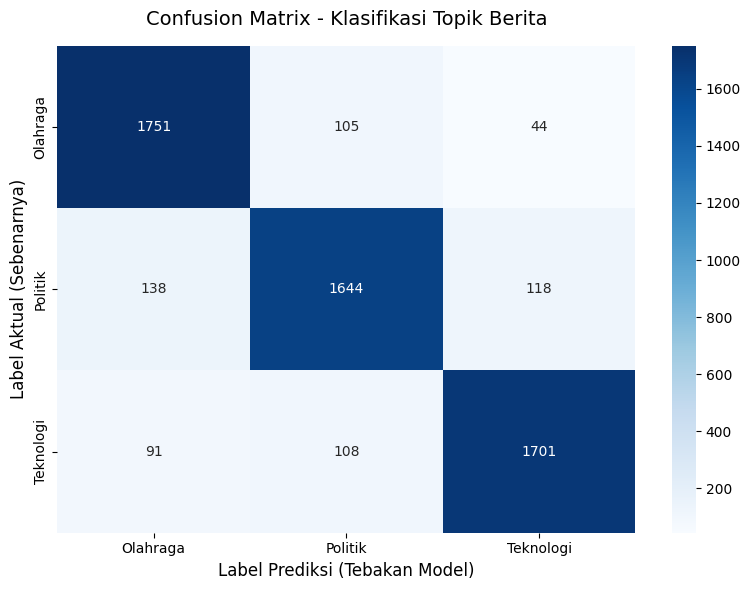

In [21]:
# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------
print("\n[B] CONFUSION MATRIX")
print("-" * 30)
print("Menampilkan visualisasi Confusion Matrix...")

# Menghitung matriks
cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

# Visualisasi dengan Seaborn untuk tampilan yang profesional
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dt_model.classes_, 
            yticklabels=dt_model.classes_)
plt.title('Confusion Matrix - Klasifikasi Topik Berita', fontsize=14, pad=15)
plt.ylabel('Label Aktual (Sebenarnya)', fontsize=12)
plt.xlabel('Label Prediksi (Tebakan Model)', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# ---------------------------------------------------------
# INTERPRETASI RULE BERBASIS TEKS
# ---------------------------------------------------------
print("\n[C] INTERPRETASI RULE (ATURAN IF-THEN)")
print("-" * 30)
print("Menampilkan 3 level pertama dari cabang Decision Tree:\n")
rule_text = export_text(dt_model, feature_names=selected_feature_words, max_depth=3)
print(rule_text)


[C] INTERPRETASI RULE (ATURAN IF-THEN)
------------------------------
Menampilkan 3 level pertama dari cabang Decision Tree:

|--- iraq <= 0.06
|   |--- microsoft <= 0.02
|   |   |--- president <= 0.07
|   |   |   |--- minister <= 0.03
|   |   |   |   |--- truncated branch of depth 353
|   |   |   |--- minister >  0.03
|   |   |   |   |--- truncated branch of depth 19
|   |   |--- president >  0.07
|   |   |   |--- company <= 0.06
|   |   |   |   |--- truncated branch of depth 69
|   |   |   |--- company >  0.06
|   |   |   |   |--- truncated branch of depth 4
|   |--- microsoft >  0.02
|   |   |--- antitrust <= 0.19
|   |   |   |--- press <= 0.21
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- press >  0.21
|   |   |   |   |--- class: Politik
|   |   |--- antitrust >  0.19
|   |   |   |--- class: Teknologi
|--- iraq >  0.06
|   |--- soccer <= 0.16
|   |   |--- online <= 0.05
|   |   |   |--- football <= 0.07
|   |   |   |   |--- truncated branch of depth 21
|   |   


[D] VISUALISASI DECISION TREE GRAFIS
------------------------------


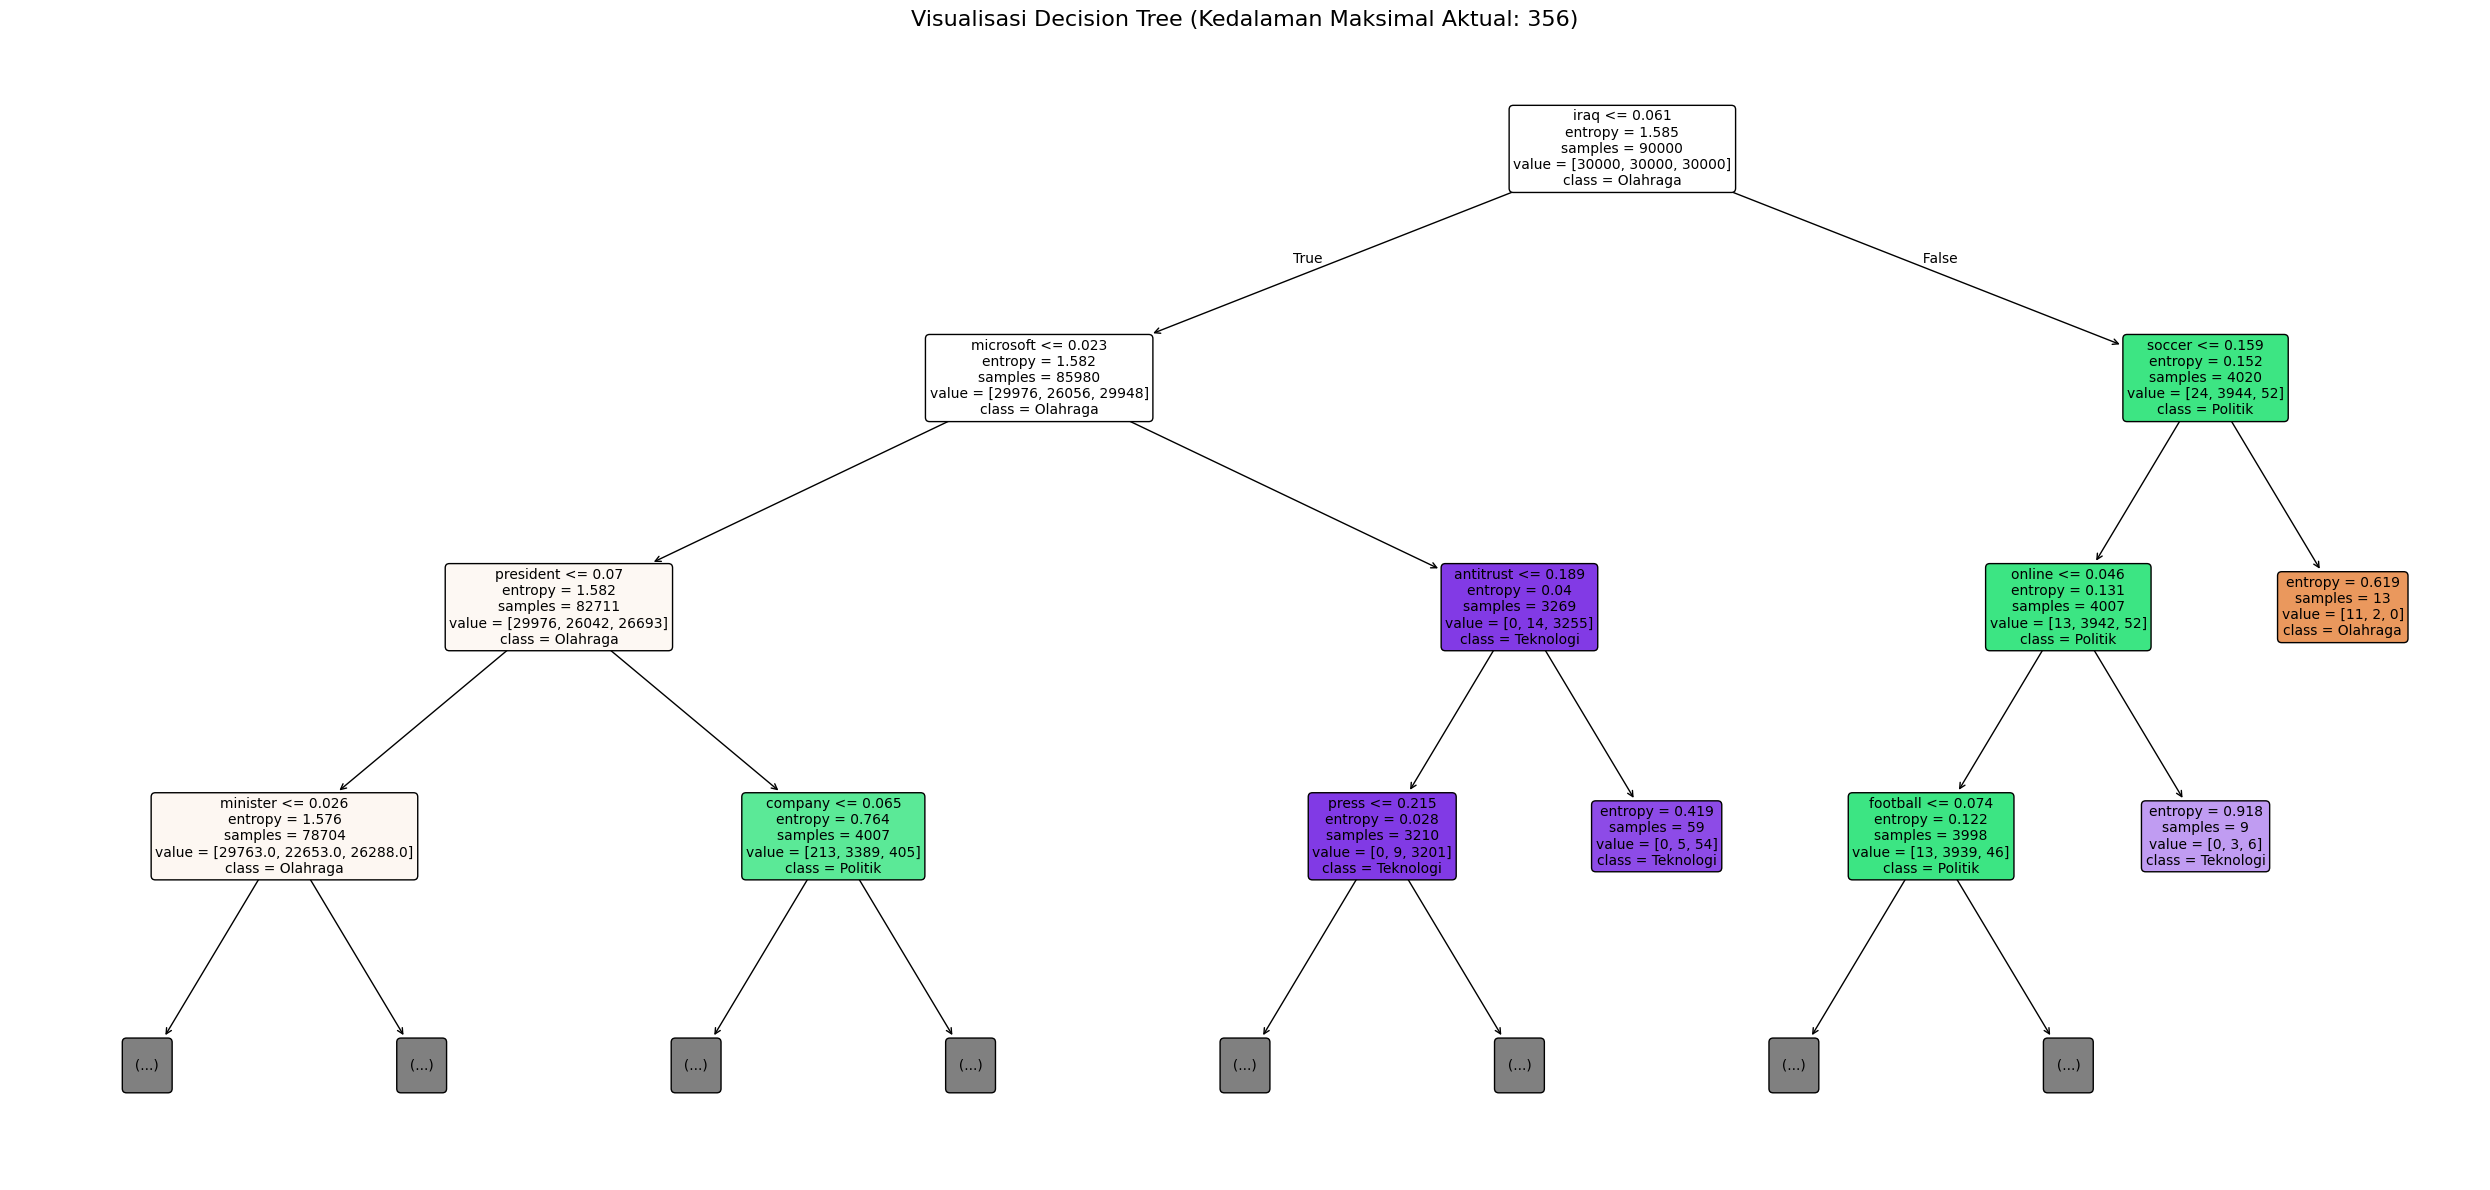

In [23]:
# ---------------------------------------------------------
# VISUALISASI DECISION TREE
# ---------------------------------------------------------
print("\n[D] VISUALISASI DECISION TREE GRAFIS")
print("-" * 30)
plt.figure(figsize=(25, 12))
plot_tree(
    dt_model, 
    feature_names=selected_feature_words, 
    class_names=dt_model.classes_, 
    filled=True, 
    rounded=True, 
    max_depth=3, # Dibatasi 3 level agar tidak terlalu bertumpuk di layar
    fontsize=10
)
plt.title(f"Visualisasi Decision Tree (Kedalaman Maksimal Aktual: {dt_model.tree_.max_depth})", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
# ---------------------------------------------------------
# ANALISIS OVERFITTING
# ---------------------------------------------------------
print("\n[E] ANALISIS OVERFITTING PADA MODEL FINAL")
print("-" * 30)

# Prediksi ulang data training untuk membandingkan
y_pred_train = dt_model.predict(X_train_final)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred)
gap = train_accuracy - test_accuracy

print(f"1. Akurasi pada Data Latih (Training) : {train_accuracy * 100:.2f}%")
print(f"2. Akurasi pada Data Uji (Testing)    : {test_accuracy * 100:.2f}%")
print(f"3. Selisih Penurunan Akurasi (Gap)    : {gap * 100:.2f}%\n")

# Penarikan Kesimpulan Otomatis
if gap > 0.15:
    print("KESIMPULAN: Model terindikasi mengalami OVERFITTING yang signifikan.")
    print("Alasan: Model sangat pintar menghafal data latih (akurasi tinggi), namun")
    print("gagal melakukan generalisasi pada data uji (akurasi anjlok).")
    print("Saran: Kurangi nilai 'max_depth' atau tambah nilai 'min_samples_split'.")
elif gap < 0.05 and train_accuracy < 0.60:
    print("KESIMPULAN: Model terindikasi mengalami UNDERFITTING.")
    print("Alasan: Akurasi data latih dan uji sama-sama rendah.")
    print("Saran: Tambah nilai 'max_depth' agar pohon bisa belajar lebih detail.")
else:
    print("KESIMPULAN: Model tergolong STABIL (Good Fit).")
    print("Alasan: Jarak antara akurasi latih dan uji masih dalam batas wajar,")
    print("sehingga model mampu melakukan generalisasi dengan baik pada data baru.")


[E] ANALISIS OVERFITTING PADA MODEL FINAL
------------------------------
1. Akurasi pada Data Latih (Training) : 92.97%
2. Akurasi pada Data Uji (Testing)    : 89.40%
3. Selisih Penurunan Akurasi (Gap)    : 3.56%

KESIMPULAN: Model tergolong STABIL (Good Fit).
Alasan: Jarak antara akurasi latih dan uji masih dalam batas wajar,
sehingga model mampu melakukan generalisasi dengan baik pada data baru.
